In [182]:
%pprint
import numpy as np 
import pandas as pd
import os
import time
import datetime

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

Pretty printing has been turned OFF


In [4]:
# Locate folder
os.chdir("D:/Python_project/Infodemics/Media_Collection")
path = "D:/Python_project/Infodemics/Media_Collection/"      

stopwords = ['allegheny','coronavirus','county','pennsylvania','virginia','additional','ohio','bringing',
             'week','year','fall','countywide','area','state','report','statewide',
            'amid', 'pittsburgh','covid','district','announces','west','local','center',
            'day','phase','virus','plan','beaver','pandemic','north','washington','link',
            'july','april','announced','percent','reporting','probable','month','thing','lot',
            'hour','hill','penn','city','bull','wear','wearing','staff','including','told',
            'august','decision','group','bar','high','stand','increase','june','needed','start',
            'today','feel','pennsylvanian','team','entire']

# Overview

In [133]:
%%time
tw_pitt =  pd.read_csv('Copy of Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh].csv', skiprows=6)
tw_pitt['Date'] = pd.to_datetime(tw_pitt.Date).dt.date
tw_pitt['date'] = pd.to_datetime(tw_pitt.Date).dt.date
tw_pitt = tw_pitt.sort_values(['Date']).reset_index()

CPU times: total: 25.1 s
Wall time: 25.3 s


In [134]:
tw_pitt.head()

,Query Id,Query Name,Date,Title,Url,Domain,Sentiment,Page Type,Language,Country Code,...,Updated,Reach (new),Copyright,Linkedin Engagement,Linkedin Impressions,Page Type Name,Reddit Score,Region,Region Code,date
0,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:50.0,"RT @stephaniemlee New story, from me: An NIH p...",http://twitter.com/mike_412/statuses/130094650...,twitter.com,neutral,twitter,en,USA,...,2020-09-22T17:59:01.821+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
1,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:39.0,RT @Leigh4USA Pelosi no mask 😷 in a hair salon...,http://twitter.com/CasaDelAngel/statuses/13009...,twitter.com,positive,twitter,en,USA,...,2020-09-22T17:59:01.820+0000,2298.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
2,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:35.0,RT @Liz_Wheeler So Pelosi gets a blowout in a ...,http://twitter.com/TheCalamityMay/statuses/130...,twitter.com,negative,twitter,en,USA,...,2020-09-22T17:59:01.821+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
3,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:33.0,Some news from Pitt's covid-19 data dashboard:...,http://twitter.com/teghan_simonton/statuses/13...,twitter.com,neutral,twitter,en,USA,...,2020-09-22T17:59:01.820+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
4,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:31.0,RT @ryanstruyk FAUCI: “The numbers that you’ve...,http://twitter.com/mike_412/statuses/130094642...,twitter.com,negative,twitter,en,USA,...,2020-09-22T17:59:01.821+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01


By checking features one-by-one, I delete features that are not useful (either emtpy, or all with the same content).\

**Some thoughts:**\
1. Individual vs organizational account: maybe only individual account?
2. Author: top authors including WPXI, KDKA, TribLIVE, PittsburghPG
3. Candidate features for potential weighting factor: 
    - **Impact**
    - **Impressions** on Twitter is a total tally of all the times the Tweet has been seen. This includes not only the times it appears in a one of your followers’ timeline but also the times it has appeared in search or as a result of someone liking the Tweet.
    - **Twitter Followers**
    - **Twitter Reply Count**
    - **Retweets**
    - **Tweets** (what is this?)
    - **Reach (new)** (what is this?)
4. **Need to do: change emoji to the explanation**
5. Most Lat, Lng is 0, thus not good for tracking the exact location
6. How to incorporate media contents (e.g. pic, video) of a twitter

In [135]:
# tw_pitt.drop(columns=['Query Name'], inplace=True)
tw_pitt = tw_pitt[tw_pitt.Domain=='twitter.com']
cols_to_be_dropped = ['Query Name', 'Language', 'Page Type', 
                      'Country Code', 'Continent Code', 'Continent', 'Country', 'City Code',
                      'Assignment', 'Avatar', 'Category Details', 'Checked', 'City', 'Display URLs',
                      'Facebook Author ID', 'Facebook Comments', 'Facebook Likes', 
                      'Facebook Role', 'Facebook Shares', 'Facebook Subtype',
                      'Instagram Comments', 'Instagram Followers', 'Instagram Following',
                      'Instagram Interactions Count', 'Instagram Likes', 'Instagram Posts',
                      'Media Filter', 'Priority', 'Starred', 'Status', 'Subtype',
                      'Total Monthly Visitors', 'Twitter Channel Role'
                      'Copyright', 'Linkedin Engagement', 'Linkedin Impressions',
                      'Page Type Name', 'Reddit Score', 'Region', 'Region Code']
cols_to_be_dropped = list(set(cols_to_be_dropped) & set(tw_pitt.columns))
tw_pitt.drop(columns=cols_to_be_dropped, inplace=True)
print(tw_pitt.columns)

Index(['Query Id', 'Date', 'Title', 'Url', 'Domain', 'Sentiment',
       'Account Type', 'Added', 'Author', 'Expanded URLs', 'Full Name',
       'Full Text', 'Gender', 'Hashtags', 'Impact', 'Impressions', 'Interest',
       'Last Assignment Date', 'Latitude', 'Location Name', 'Longitude',
       'Media URLs', 'Mentioned Authors', 'Original Url', 'Professions',
       'Resource Id', 'Short URLs', 'Thread Author', 'Thread Created Date',
       'Thread Entry Type', 'Thread Id', 'Thread URL', 'Twitter Author ID',
       'Twitter Channel Role', 'Twitter Followers', 'Twitter Following',
       'Twitter Reply Count', 'Twitter Reply to', 'Twitter Retweet of',
       'Twitter Retweets', 'Twitter Tweets', 'Twitter Verified', 'Updated',
       'Reach (new)', 'Copyright', 'date'],
      dtype='object')


# Cleaning - DF

In [157]:
def clean_df( df, nonempty_features ): 
    
    # nonempty_features = ['Date', 'Full Text']
    # show null values
    plt.figure(figsize = (15,5))
    sns.heatmap(df.isnull(), cbar = False, cmap = 'YlGnBu')
    plt.show()  # few data without summary
    
    a = df.isnull().apply(lambda x : sum(x[nonempty_features]) >= 1 , axis = 1)
    drop_ob_indexs = a[a==True].index
    print("There are ", len(drop_ob_indexs), " empty observations needed to be removed." )
    
    df = df.drop(drop_ob_indexs)
          
    # drop duplicated obs
    Obnum_before = df.shape[0]
    df = df[ ~ df.duplicated() ]
    Obnum_after = df.shape[0]
    df.index = range(df.shape[0]) 
    
    Num_of_dup = Obnum_before - Obnum_after
    print(" " )
    print("There are ", Num_of_dup, " duplicated values in the data set." ) 
    
    return df

In [137]:
tw_pitt['is_retweet'] = tw_pitt.Title.apply(lambda x: 1 if x[:2]=='RT' else 0)
tw_pitt.date.value_counts()
# .sample(5)

2020-03-12    21635
2020-03-13    20432
2020-03-16    18956
2020-03-19    18387
2020-03-17    18366
              ...  
2020-01-14       53
2020-01-12       52
2020-01-19       52
2020-01-08       51
2020-01-11       36
Name: date, Length: 245, dtype: int64

In [138]:
tw_pitt[['Title', 'Full Text', 'is_retweet']].sample(5)

,Title,Full Text,is_retweet
869885,RT @cmyeaton This is the moment I warned of - ...,RT @cmyeaton This is the moment I warned of - ...,1
409827,RT @Redhead4645 Neil Cavuto reacts to Trump ta...,RT @Redhead4645 Neil Cavuto reacts to Trump ta...,1
866172,"Critical in the fight against #COVID19, 27,000...","Critical in the fight against #COVID19, 27,000...",0
543263,RT @Fred_Delicious imagine explaining this twe...,RT @Fred_Delicious imagine explaining this twe...,1
40086,COVID-19 virus mutation that is '10 times' mor...,COVID-19 virus mutation that is '10 times' mor...,0


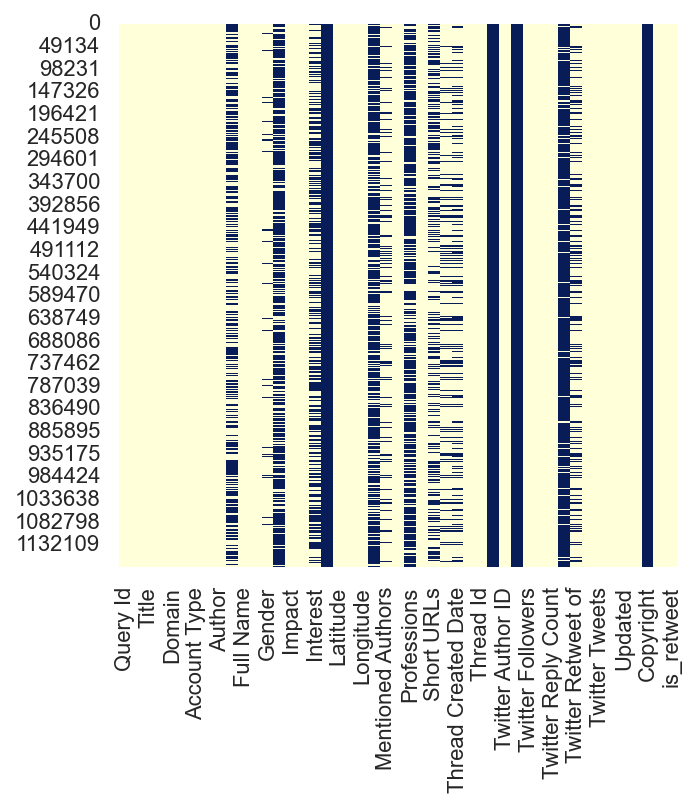

There are  0  empty observations needed to be removed.
 
There are  0  duplicated values in the data set.
CPU times: total: 6min 59s
Wall time: 6min 59s


In [139]:
%%time
tw_pitt = clean_df( tw_pitt, nonempty_features = ['Date', 'Full Text'] )

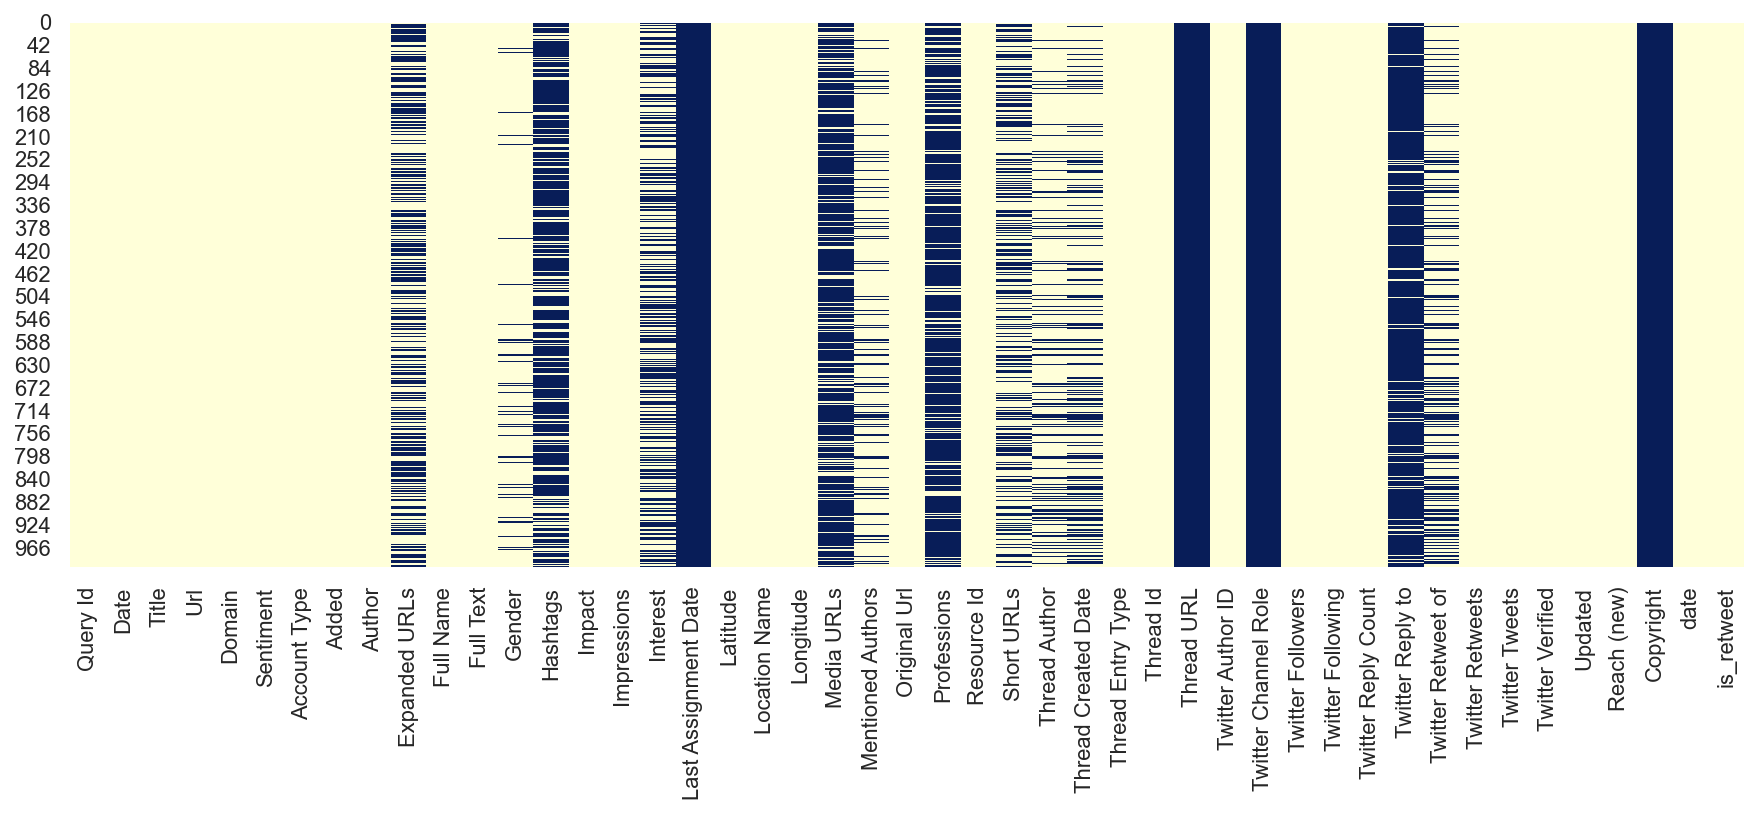

In [144]:
plt.figure(figsize = (15,5))
sns.heatmap(tw_pitt.head(1000).isnull(), cbar = False, cmap = 'YlGnBu')
plt.show()  # few data without summary

In [154]:
# drop useless columns
cols_to_be_dropped = ['Expanded URLs','Hashtags','Interest','Last Assignment Date','Media URLs',
                      'Professions','Short URLs', 'Thread Author', 'Thread Created Date','Thread URL',
                      'Twitter Channel Role','Twitter Reply to', 'Twitter Retweet of','Copyright','Mentioned Authors'
                      'Gender']
tw_pitt.drop(columns=cols_to_be_dropped, inplace=True)

<AxesSubplot:>

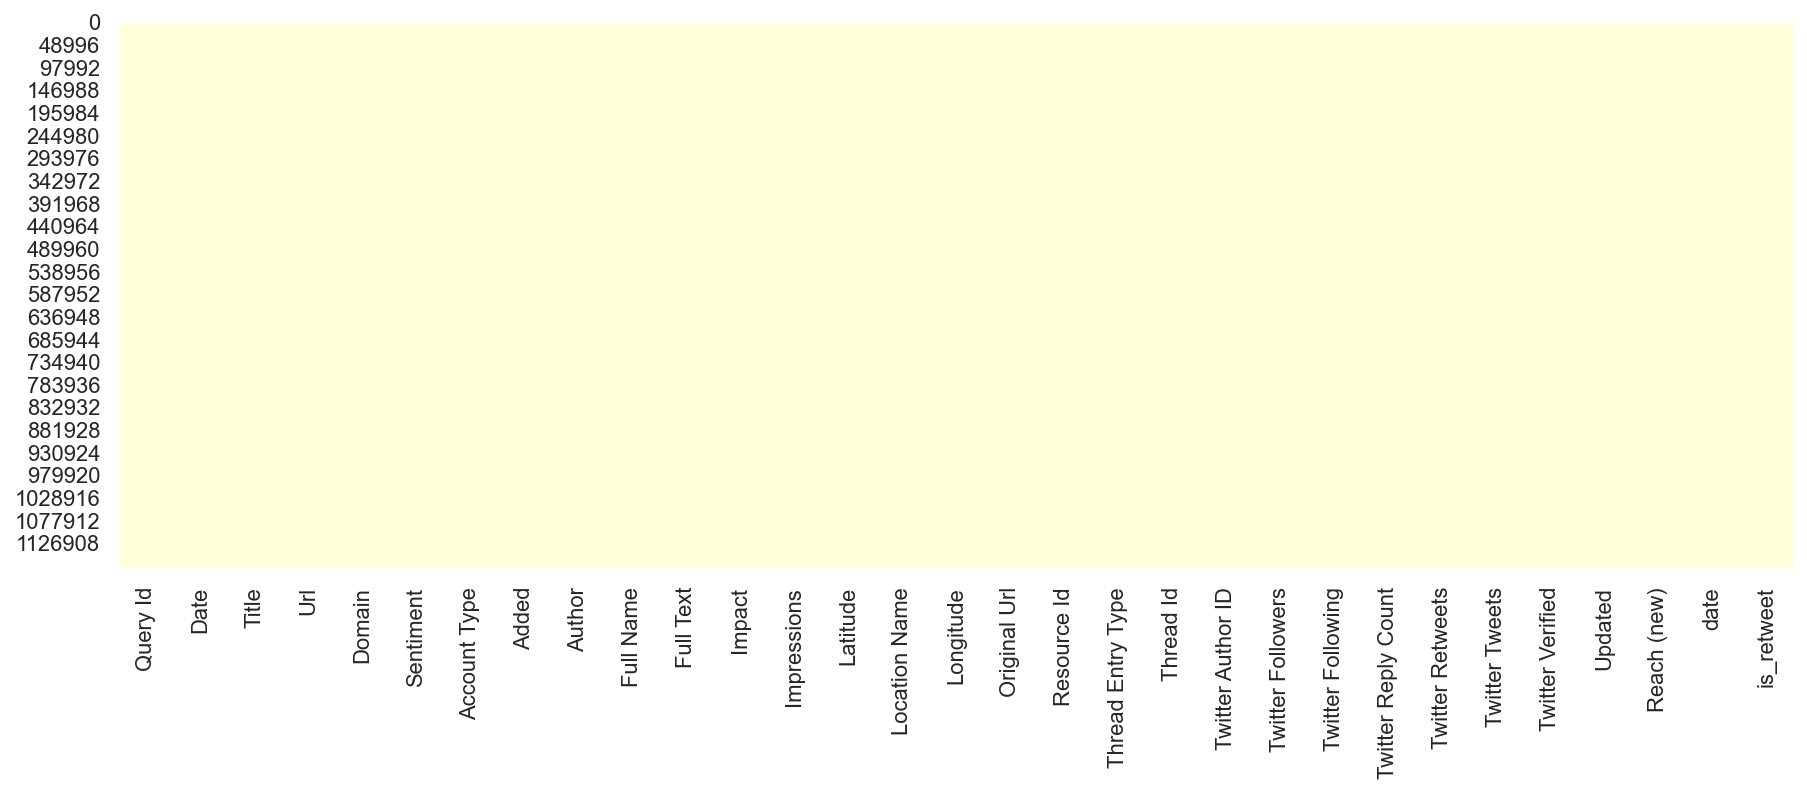

In [156]:
plt.figure(figsize = (15,5))
sns.heatmap(tw_pitt.isnull(), cbar = False, cmap = 'YlGnBu')

# Cleaning - Text

In [37]:
tw_pitt.Title.tolist()[:10]

["RT @stephaniemlee New story, from me: An NIH panel said there's no good data to show that convalescent plasma treats the coronavirus, contradicting Trump. https://t.co/hEsPaA33ZK",
 'RT @Leigh4USA Pelosi no mask 😷 in a hair salon!\n👇🙄\n\nRT Pass the stimulus Bill!\n@Leigh4USA 🇺🇸 We paid for that👇\nhttps://t.co/PTIFZwp914',
 'RT @Liz_Wheeler So Pelosi gets a blowout in a hair salon (without a mask), but YOU are not allowed. That’s all you need to know about the politicians wrecking our economy in the name of COVID-19.',
 "Some news from Pitt's covid-19 data dashboard: https://t.co/8YvyjqnIQq",
 'RT @ryanstruyk FAUCI: “The numbers that you’ve been hearing, the 180,000+ deaths, are real deaths from COVID-19. Let there not be any confusion about that. It’s not 9,000 deaths from COVID-19. It’s 180,000+ deaths.”',
 '@NYGovCuomo You literally caused the high COVID statistics in your city.  I mean, they were the highest in the country, and most places in the world.  Sit. This. One. Out. Bro.

In [38]:
tw_pitt['Full Text'].tolist()[:10]

["RT @stephaniemlee New story, from me: An NIH panel said there's no good data to show that convalescent plasma treats the coronavirus, contradicting Trump. https://t.co/hEsPaA33ZK",
 'RT @Leigh4USA Pelosi no mask 😷 in a hair salon! 👇🙄 RT Pass the stimulus Bill! @Leigh4USA 🇺🇸 We paid for that👇 https://t.co/PTIFZwp914',
 'RT @Liz_Wheeler So Pelosi gets a blowout in a hair salon (without a mask), but YOU are not allowed. That’s all you need to know about the politicians wrecking our economy in the name of COVID-19.',
 "Some news from Pitt's covid-19 data dashboard: https://t.co/8YvyjqnIQq",
 'RT @ryanstruyk FAUCI: “The numbers that you’ve been hearing, the 180,000+ deaths, are real deaths from COVID-19. Let there not be any confusion about that. It’s not 9,000 deaths from COVID-19. It’s 180,000+ deaths.”',
 '@NYGovCuomo You literally caused the high COVID statistics in your city. I mean, they were the highest in the country, and most places in the world. Sit. This. One. Out. Bro... and y

In [176]:
import re
from tqdm import tqdm

from nltk.corpus import stopwords as stpw
from nltk.stem.wordnet import WordNetLemmatizer
from nltk import word_tokenize, pos_tag # nltk.download('averaged_perceptron_tagger')
 
# lemmatization
lemma = WordNetLemmatizer() 

# stop words
def update_stopwords():
    stopwords = []
    with open("stopwords_en.txt", "r") as f1:
        for stopword in f1.readlines():
            stopwords.append(stopword.strip('\n'))
        
    with open("extra_stopwords_en.txt", "r") as f2:
        for stopword in f2.readlines():
            stopwords.append(stopword.strip('\n'))

    stopwords.extend(extr_stopwords)
    stopwords.extend(stpw.words('english'))
    stopwords = set(stopwords)
    return stopwords

stopwords = update_stopwords()

In [174]:
# Cleaning functions
def replace_words(temp):
    # temp = tweet.lower()
    temp = temp.replace('covid 19' , 'covid19')
    temp = temp.replace('covid-19' , 'covid19')
    temp = temp.replace('hong kong' , 'hongkong')
    temp = temp.replace('wu han' , 'wuhan') 
    temp = temp.replace('tests' , 'test')
    temp = temp.replace('tested' , 'test')
    temp = temp.replace('testing' , 'test')
    temp = temp.replace('reopening' , 'reopen')
    temp = temp.replace('ppl' , 'people')
    temp = temp.replace('rt ' , '')
    return temp

def filter_words(temp):
    # temp = tweet.lower()  
    # fist filter
    temp = [w for w in temp.split(' ') if not w in stopwords]
    temp = " ".join(word for word in temp)
    # to avoid removing contractions in english
    temp = re.sub("'", "", temp) 
    # Removing hashtags and mentions
    temp = re.sub("@[A-Za-z0-9_]+","", temp)
    temp = re.sub("#[A-Za-z0-9_]+","", temp)
    # Removing links
    temp = re.sub(r"http\S+", "", temp)
    temp = re.sub(r"www.\S+", "", temp)
    # Removing punctuations
    temp = re.sub('[()!?]', ' ', temp)
    temp = re.sub('\[.*?\]',' ', temp)
    # Filtering non-alphanumeric characters
    temp = re.sub("[^a-z0-9]"," ", temp)
    return temp

def convert_postag(word2pos):
    # word2pos = ('eating', 'VBG')
    word = word2pos[0]
    tag = word2pos[1]
    
    if tag.startswith('J'):
        tag = 'a'
    elif tag.startswith('V'):
        tag = 'v'
    elif tag.startswith('N'):
        tag = 'n'
    elif tag.startswith('R'):
        tag = 'r'
    else:
        tag = 'skip'
        
    return (word,tag)

def filter_useful_pos(temp):
    wordlst = word_tokenize(temp)
    word2pos_lst = pos_tag(wordlst)
    word2pos_lst = [convert_postag(word2pos) for word2pos in word2pos_lst]
    word2pos_lst = [word2pos for word2pos in word2pos_lst if not word2pos[1] == 'skip']
    return word2pos_lst

def clean_tweet(tweet):
    # print(tweet)
    temp = tweet.lower()
    temp = filter_words(temp)
    temp = replace_words(temp)
    
    word2pos_lst = filter_useful_pos(temp)
    temp = [WordNetLemmatizer().lemmatize(word2pos[0],word2pos[1]) for word2pos in word2pos_lst ]
    # second filter
    temp = [w for w in temp if not w in stopwords]
    temp = " ".join(word for word in temp)
    # print(temp)
    return temp

In [112]:
# Notes
'''
                            WordNetLemmatizer().lemmatize( word , pos: str = "n" )

                                        "n" for nouns (default),
                                        "v" for verbs, 
                                        "a" for adjectives, 
                                        "r" for adverbs 
                                        "s" for satellite adjectives.
'''
        
WordNetLemmatizer().lemmatize('eating','v') # eat
WordNetLemmatizer().lemmatize('eating')     # eating


'''
                            # Get pos 词性

                            from nltk import word_tokenize, pos_tag
                            # nltk.download('averaged_perceptron_tagger')

                            pos_tag(wordslst) 

'''

pos_tag(["eat"])

[('eat', 'NN')]

In [177]:
%%time
cleaned_tweets = tw_pitt['Full Text'].apply(lambda x: clean_tweet(x))

CPU times: total: 25min 28s
Wall time: 25min 28s


In [178]:
tw_pitt['cleaned_text'] = cleaned_tweets
tw_pitt.head(400)

,Query Id,Date,Title,Url,Domain,Sentiment,Account Type,Added,Author,Full Name,...,Twitter Following,Twitter Reply Count,Twitter Retweets,Twitter Tweets,Twitter Verified,Updated,Reach (new),date,is_retweet,cleaned_text
0,2000359647,2020-09-01,"RT @stephaniemlee New story, from me: An NIH p...",http://twitter.com/mike_412/statuses/130094650...,twitter.com,neutral,individual,2020-09-22T17:59:01.821+0000,mike_412,mike_412 (Michael Brourman),...,993,0,0,55609,False,2020-09-22T17:59:01.821+0000,0.0,2020-09-01,1,story nih panel good data convalescent plasma ...
1,2000359647,2020-09-01,RT @Leigh4USA Pelosi no mask 😷 in a hair salon...,http://twitter.com/CasaDelAngel/statuses/13009...,twitter.com,positive,individual,2020-09-22T17:59:01.820+0000,CasaDelAngel,CasaDelAngel (❌CasaDelAngel®️™️🇺🇸Parler),...,2036,0,0,172719,False,2020-09-22T17:59:01.820+0000,2298.0,2020-09-01,1,pelosi mask hair salon stimulus pay
2,2000359647,2020-09-01,RT @Liz_Wheeler So Pelosi gets a blowout in a ...,http://twitter.com/TheCalamityMay/statuses/130...,twitter.com,negative,individual,2020-09-22T17:59:01.821+0000,TheCalamityMay,TheCalamityMay (CalamityMay),...,297,0,0,2373,False,2020-09-22T17:59:01.821+0000,0.0,2020-09-01,1,pelosi hair salon mask politician wreck econom...
3,2000359647,2020-09-01,Some news from Pitt's covid-19 data dashboard:...,http://twitter.com/teghan_simonton/statuses/13...,twitter.com,neutral,individual,2020-09-22T17:59:01.820+0000,teghan_simonton,teghan_simonton (Teghan Simonton),...,305,0,0,780,False,2020-09-22T17:59:01.820+0000,0.0,2020-09-01,0,news pitt covid19 data dashboard
4,2000359647,2020-09-01,RT @ryanstruyk FAUCI: “The numbers that you’ve...,http://twitter.com/mike_412/statuses/130094642...,twitter.com,negative,individual,2020-09-22T17:59:01.821+0000,mike_412,mike_412 (Michael Brourman),...,993,0,0,55607,False,2020-09-22T17:59:01.821+0000,0.0,2020-09-01,1,fauci number hear death real death covid19 con...


In [244]:
# Furter clean

def filter_words2(temp):
    # temp = tweet.lower()  
    # fist filter
    temp = [w for w in temp.split(' ') if not w in stopwords]
    temp = [w for w in temp if len(w)>2]
    
    temp = " ".join(word for word in temp)
    return temp

In [208]:
%%time
cleaned_tweets = tw_pitt['cleaned_text'].apply(lambda x: filter_words2(x))
tw_pitt['cleaned_text'] = cleaned_tweets
print('Total',(tw_pitt['cleaned_text'].apply(len)==0).sum(),'empty texts')

Total 5410 empty texts
CPU times: total: 3.58 s
Wall time: 3.59 s


In [209]:
drop_obs = tw_pitt[(tw_pitt['cleaned_text'].apply(len)==0)].index
tw_pitt = tw_pitt.drop(drop_obs).reset_index()
print('Total',(tw_pitt['cleaned_text'].apply(len)==0).sum(),'empty texts')

Total 0 empty texts


In [218]:
tw_pitt.head()

,level_0,index,Query Id,Date,Title,Url,Domain,Sentiment,Account Type,Added,...,Twitter Following,Twitter Reply Count,Twitter Retweets,Twitter Tweets,Twitter Verified,Updated,Reach (new),date,is_retweet,cleaned_text
0,1170486,1175896,2000359647,2020-01-01,RT @chadthemaverick TAURUS ♉️🌳 \nYou’re cruisi...,http://twitter.com/Rogue_Batgirl/statuses/1212...,twitter.com,neutral,individual,2020-09-22T17:58:54.213+0000,...,673,0,0,8624,False,2020-09-22T17:58:54.213+0000,0.0,2020-01-01,1,taurus cruise horse honesty deserve recognitio...
1,1170479,1175889,2000359647,2020-01-01,RT @PahlNancy Trump gets Kathy Griffin blackba...,http://twitter.com/moon15116/statuses/12122547...,twitter.com,neutral,individual,2020-09-22T17:58:54.213+0000,...,5694,0,0,154485,False,2020-09-22T17:58:54.213+0000,3129.0,2020-01-01,1,trump kathy griffin blackball point pose mask ...
2,1170450,1175860,2000359647,2020-01-01,Mother says Yes To unicorn face mask burned st...,http://twitter.com/WPXI/statuses/1212432058456...,twitter.com,neutral,individual,2020-09-22T17:58:54.218+0000,...,3547,1,0,317744,True,2020-09-22T17:58:54.218+0000,23128.0,2020-01-01,0,mother unicorn face mask burn stepdaughter face
3,1170484,1175894,2000359647,2020-01-01,RT @JDMorgan Gus found the comedian mask. Stil...,http://twitter.com/mrpshropshire/statuses/1212...,twitter.com,positive,individual,2020-09-22T17:58:54.212+0000,...,5002,0,0,302792,False,2020-09-22T17:58:54.212+0000,1744.0,2020-01-01,1,comedian mask fit glove extra extra badass bif...
4,1170483,1175893,2000359647,2020-01-01,"#NowPlaying ""Faucet Failure"" by Ski Mask the S...",http://twitter.com/FCWHHARadioShow/statuses/12...,twitter.com,negative,organisational,2020-09-22T17:58:54.212+0000,...,416,0,0,45237,False,2020-09-22T17:58:54.212+0000,0.0,2020-01-01,0,faucet failure ski mask slump god


In [219]:
tw_pitt.to_csv('tw_pitt_cleaned.csv', index=False)
tw_pitt[['Date', 'cleaned_text','is_retweet']].to_csv('tw_pitt_cleaned_onlytext.csv', index=False)

# Only Verb & None

In [220]:
tw_pitt = pd.read_csv('tw_pitt_cleaned_onlytext.csv')

In [222]:
tw_pitt

,Date,cleaned_text,is_retweet
0,2020-01-01,taurus cruise horse honesty deserve recognitio...,1
1,2020-01-01,trump kathy griffin blackball point pose mask ...,1
2,2020-01-01,mother unicorn face mask burn stepdaughter face,0
3,2020-01-01,comedian mask fit glove extra extra badass bif...,1
4,2020-01-01,faucet failure ski mask slump god,0
...,...,...,...
1170482,2020-09-01,pelosi mask hair salon stimulus pay,1
1170483,2020-09-01,lady gaga heard performer mask dancer send wro...,1
1170484,2020-09-01,german study recovered covid19 patient persist...,1
1170485,2020-09-01,ing operate law party leader talk blow person ing,1


In [235]:
def filter_noneNVtag(word2pos):
    # word2pos = ('eating', 'VBG')
    word = word2pos[0]
    tag = word2pos[1]
    
    if tag.startswith('V') or tag.startswith('N'):
        return (word,tag)
    else:
        tag = 'skip'    
    return (word,tag)

def none_and_verb(temp):
    wordlst = word_tokenize(temp)
    word2pos_lst = pos_tag(wordlst)
    word2pos_lst = [filter_noneNVtag(word2pos) for word2pos in word2pos_lst]
    word2pos_lst = [word2pos for word2pos in word2pos_lst if not word2pos[1] == 'skip']
    wordlst = [word2pos[0] for word2pos in word2pos_lst ]
    temp = " ".join(wordlst)
    return temp

In [236]:
# test function
temp = tw_pitt.iloc[1,1]
print(temp)
print(none_and_verb(temp))

trump kathy griffin blackball point pose mask pardon killer navy seal selfies execute prisoner
trump kathy griffin blackball point pose mask pardon killer seal selfies execute prisoner


In [241]:
%%time
cleaned_verb_noun = tw_pitt['cleaned_text'].apply(lambda x: none_and_verb(x))
tw_pitt['cleaned_text_verb_noun'] = cleaned_verb_noun

CPU times: total: 22min 15s
Wall time: 22min 15s


In [242]:
tw_pitt.to_csv('tw_pitt_cleaned_onlytext.csv', index=False)

In [243]:
tw_pitt

,Date,cleaned_text,is_retweet,cleaned_text_verb_noun
0,2020-01-01,taurus cruise horse honesty deserve recognitio...,1,taurus cruise horse honesty deserve recognitio...
1,2020-01-01,trump kathy griffin blackball point pose mask ...,1,trump kathy griffin blackball point pose mask ...
2,2020-01-01,mother unicorn face mask burn stepdaughter face,0,mother face mask burn stepdaughter face
3,2020-01-01,comedian mask fit glove extra extra badass bif...,1,mask fit glove badass bifocals mask comeback
4,2020-01-01,faucet failure ski mask slump god,0,failure mask slump god
...,...,...,...,...
1170482,2020-09-01,pelosi mask hair salon stimulus pay,1,pelosi mask hair stimulus pay
1170483,2020-09-01,lady gaga heard performer mask dancer send wro...,1,gaga heard mask dancer send message level powe...
1170484,2020-09-01,german study recovered covid19 patient persist...,1,study recovered inflammation lead investigator...
1170485,2020-09-01,ing operate law party leader talk blow person ing,1,ing operate law party leader talk person ing


In [253]:
tw_pitt[tw_pitt['is_retweet']==0].Date.value_counts().sort_index()

2020-01-01     25
2020-01-02     46
2020-01-03     39
2020-01-04     28
2020-01-05     25
             ... 
2020-08-28    823
2020-08-29    633
2020-08-30    547
2020-08-31    794
2020-09-01    860
Name: Date, Length: 245, dtype: int64

In [13]:
tw_pitt.is_retweet.value_counts()

1    861677
0    314220
Name: is_retweet, dtype: int64

In [254]:
original_tw_pitt = tw_pitt[tw_pitt.is_retweet==0]
original_tw_pitt = original_tw_pitt.sort_index()

In [255]:
original_tw_pitt

,Date,cleaned_text,is_retweet,cleaned_text_verb_noun
2,2020-01-01,mother unicorn face mask burn stepdaughter face,0,mother face mask burn stepdaughter face
4,2020-01-01,faucet failure ski mask slump god,0,failure mask slump god
7,2020-01-01,happy celebrate officially delete patreon fanc...,0,celebrate patreon clay mask night fell choice
9,2020-01-01,mask slip dark face moment normal behavior pope,0,mask slip face moment behavior pope
15,2020-01-01,lockdown,0,lockdown
...,...,...,...,...
1170453,2020-09-01,joe bidens continue democrat nominate,0,joe bidens continue nominate
1170462,2020-09-01,neighbor scream lived street problem friend bl...,0,neighbor scream lived street problem friend bl...
1170465,2020-09-01,trump white house penny deborah birx warn coll...,0,house penny deborah birx warn college send cov...
1170478,2020-09-01,literally caused statistic country place sit b...,0,caused country place sit bro catch walk dog mask


In [256]:
original_tw_pitt.to_csv('tw_pitt_original_cleaned.csv', index=False)

# Tweets By Day

In [264]:
# Data Type 
tw_pitt_text2day  = tw_pitt[['Date','cleaned_text']]           # All text
tw_pitt_VN2day    = tw_pitt[['Date','cleaned_text_verb_noun']] # All verb and none
original_text2day = original_tw_pitt[['Date','cleaned_text']]  # original text
original_VN2day   = original_tw_pitt[['Date','cleaned_text_verb_noun']]  # qriginal verb and none

In [268]:
def sumstr(df):
    return ' '.join(list(df.iloc[:,1]))

In [270]:
tw_pitt_text2day  = tw_pitt_text2day.groupby('Date').apply(lambda df: sumstr(df))
tw_pitt_VN2day    = tw_pitt_VN2day.groupby('Date').apply(lambda df: sumstr(df))
original_text2day = original_text2day.groupby('Date').apply(lambda df: sumstr(df))
original_VN2day   = original_VN2day.groupby('Date').apply(lambda df: sumstr(df))

In [291]:
tw_pitt_text2day.to_csv('Doc1_text2day.csv', index=True)
tw_pitt_VN2day.to_csv('Doc2_VN2day.csv', index=True)   
original_text2day.to_csv('Doc3_original_text2day.csv', index=True)
original_VN2day.to_csv('Doc4_original_VN2day.csv', index=True)